In [13]:
import numpy as np
import cv2
import cupy as cp
from cupy.cuda import texture as tex
from time import perf_counter
import matplotlib.pyplot as plt

In [14]:
# CPU реализация

def _spatial_weight(dx, dy, sigma_d):
    """Пространственный вес (зависит от расстояния до центра)"""
    return np.exp(-(dx*dx + dy*dy) / (sigma_d * sigma_d))

def _range_weight(diff, sigma_r):
    """Диапазонный вес (зависит от разницы яркостей)"""
    return np.exp(-(diff * diff) / (sigma_r * sigma_r))

def _compute_normalization(block_3x3, center_val, sigma_d, sigma_r):
    """Вычисляет нормировочную константу k"""
    k = 0.0
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            g = _spatial_weight(dx, dy, sigma_d)
            r = _range_weight(block_3x3[1+dy, 1+dx] - center_val, sigma_r)
            k += g * r
    return k

def _compute_filtered_value(block_3x3, center_val, sigma_d, sigma_r, k):
    """Вычисляет новое значение пикселя h(a0)"""
    accum = 0.0
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            g = _spatial_weight(dx, dy, sigma_d)
            neighbor = block_3x3[1+dy, 1+dx]
            r = _range_weight(neighbor - center_val, sigma_r)
            accum += neighbor * g * r
    return accum / k if k > 1e-8 else center_val

def bilateral_filter_cpu(image_gray, sigma_d, sigma_r):
    """CPU версия двустороннего фильтра (3×3)"""
    h, w = image_gray.shape
    padded = np.pad(image_gray, 1, mode='edge')
    output = np.zeros_like(image_gray, dtype=np.float32)

    start = perf_counter()
    for i in range(h):
        for j in range(w):
            block = padded[i:i+3, j:j+3]
            center = block[1, 1]
            k_norm = _compute_normalization(block, center, sigma_d, sigma_r)
            output[i, j] = _compute_filtered_value(block, center, sigma_d, sigma_r, k_norm)
    elapsed = perf_counter() - start
    return output, elapsed

In [15]:
# GPU реализация с текстурной памятью

def bilateral_filter_gpu(image_gray, sigma_d, sigma_r):
    """GPU версия с использованием текстурной памяти"""
    h, w = image_gray.shape
    pad = 1
    padded = np.pad(image_gray, pad, mode='edge').astype(np.float32)
    img_gpu = cp.asarray(padded)

    channel_desc = tex.ChannelFormatDescriptor(
        32, 0, 0, 0,
        cp.cuda.runtime.cudaChannelFormatKindFloat
    )
    cu_array = tex.CUDAarray(channel_desc, w + 2*pad, h + 2*pad)
    cu_array.copy_from(img_gpu)
    res_desc = tex.ResourceDescriptor(cp.cuda.runtime.cudaResourceTypeArray, cu_array)
    tex_desc = tex.TextureDescriptor(
        addressModes=[cp.cuda.runtime.cudaAddressModeClamp] * 2,
        filterMode=cp.cuda.runtime.cudaFilterModeLinear,
        readMode=cp.cuda.runtime.cudaReadModeElementType,
        normalizedCoords=False
    )
    texture_object = tex.TextureObject(res_desc, tex_desc)
    kernel_code = r'''
    __device__ float spatialWeight(int dx, int dy, float sigma_d) {
        return expf(-(dx*dx + dy*dy) / (sigma_d * sigma_d));
    }

    __device__ float rangeWeight(float diff, float sigma_r) {
        return expf(-(diff * diff) / (sigma_r * sigma_r));
    }

    __device__ float computeNorm(float* window, float center, int rad,
                                 float sigma_d, float sigma_r) {
        float norm = 0.0f;
        for (int y = -rad; y <= rad; ++y) {
            for (int x = -rad; x <= rad; ++x) {
                int idx = (y + rad) * (2*rad+1) + (x + rad);
                float g = spatialWeight(x, y, sigma_d);
                float r = rangeWeight(window[idx] - center, sigma_r);
                norm += g * r;
            }
        }
        return norm;
    }

    __device__ float computeFiltered(float* window, float center, int rad,
                                     float sigma_d, float sigma_r, float norm) {
        float sum = 0.0f;
        for (int y = -rad; y <= rad; ++y) {
            for (int x = -rad; x <= rad; ++x) {
                int idx = (y + rad) * (2*rad+1) + (x + rad);
                float g = spatialWeight(x, y, sigma_d);
                float r = rangeWeight(window[idx] - center, sigma_r);
                sum += window[idx] * g * r;
            }
        }
        return (norm > 1e-6f) ? (sum / norm) : center;
    }

    extern "C" __global__ void bilateralKernel(cudaTextureObject_t tex,
                                               float* output, int width, int height,
                                               float sigma_d, float sigma_r, int pad) {
        int x = blockIdx.x * blockDim.x + threadIdx.x;
        int y = blockIdx.y * blockDim.y + threadIdx.y;
        if (x >= width || y >= height) return;

        int tx = x + pad;
        int ty = y + pad;
        int rad = 1;
        int winSize = 2*rad + 1;
        float window[9];

        int idx = 0;
        for (int dy = -rad; dy <= rad; ++dy) {
            for (int dx = -rad; dx <= rad; ++dx) {
                window[idx++] = tex2D<float>(tex, tx + dx + 0.5f, ty + dy + 0.5f);
            }
        }

        float center = window[rad * winSize + rad];
        float norm = computeNorm(window, center, rad, sigma_d, sigma_r);
        float result = computeFiltered(window, center, rad, sigma_d, sigma_r, norm);
        output[y * width + x] = result;
    }
    '''

    module = cp.RawModule(code=kernel_code, backend='nvrtc')
    kernel_func = module.get_function('bilateralKernel')

    output_gpu = cp.zeros((h, w), dtype=cp.float32)
    block_dim = (16, 16, 1)
    grid_dim = ((w + 15) // 16, (h + 15) // 16, 1)

    start_event = cp.cuda.Event()
    end_event = cp.cuda.Event()
    start_event.record()

    kernel_func(grid_dim, block_dim, (
        texture_object,
        output_gpu.data.ptr,
        np.int32(w),
        np.int32(h),
        np.float32(sigma_d),
        np.float32(sigma_r),
        np.int32(pad)
    ))

    end_event.record()
    end_event.synchronize()
    gpu_time_ms = cp.cuda.get_elapsed_time(start_event, end_event)
    gpu_time = gpu_time_ms / 1000.0

    result = cp.asnumpy(output_gpu)
    return result, gpu_time

Загружено изображение: boat.bmp, размер (512, 512)
Время GPU: 0.0001 секунд
Время CPU: 15.7771 секунд
Ускорение GPU: 122706.31x

Результаты сохранены: output_gpu.bmp, output_cpu.bmp


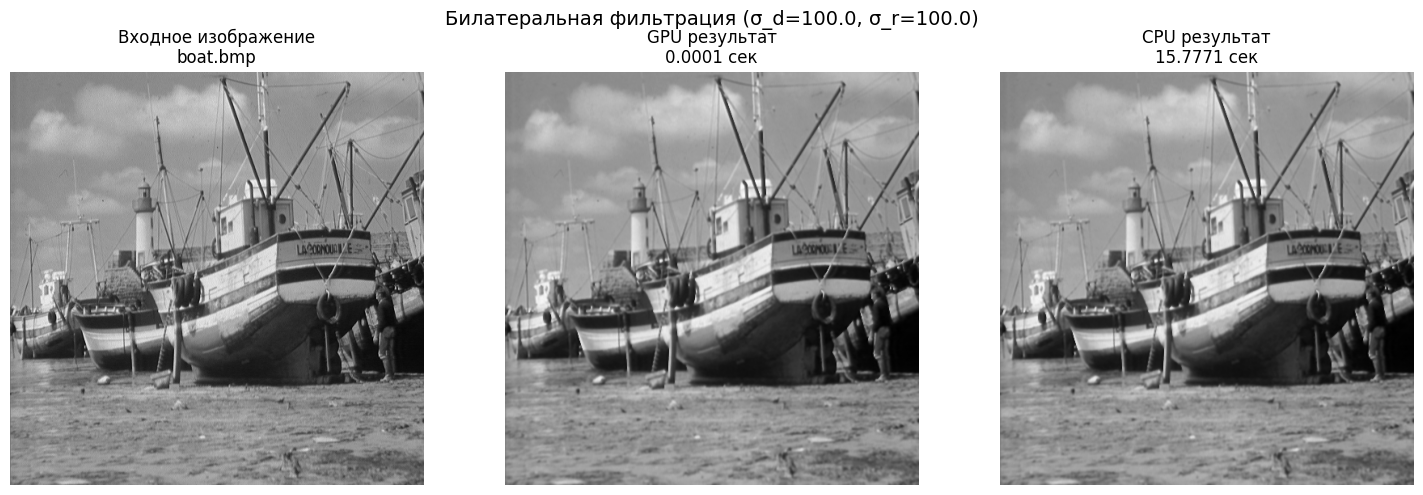

In [16]:
# Основная программа
if __name__ == "__main__":

    input_filename = "boat.bmp"
    img = cv2.imread(input_filename, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Файл {input_filename} не найден.")

    img_float = img.astype(np.float32)
    print(f"Загружено изображение: {input_filename}, размер {img.shape}")

    sigma_spatial = 100.0   # σ_d
    sigma_range = 100.0     # σ_r

    # GPU обработка
    filtered_gpu, time_gpu = bilateral_filter_gpu(img_float, sigma_spatial, sigma_range)
    print(f"Время GPU: {time_gpu:.4f} секунд")

    # CPU обработка
    filtered_cpu, time_cpu = bilateral_filter_cpu(img_float, sigma_spatial, sigma_range)
    print(f"Время CPU: {time_cpu:.4f} секунд")
    print(f"Ускорение GPU: {time_cpu / time_gpu:.2f}x")

    gpu_out_uint8 = np.clip(filtered_gpu, 0, 255).astype(np.uint8)
    cpu_out_uint8 = np.clip(filtered_cpu, 0, 255).astype(np.uint8)

    cv2.imwrite("output_gpu.bmp", gpu_out_uint8)
    cv2.imwrite("output_cpu.bmp", cpu_out_uint8)
    print("\nРезультаты сохранены: output_gpu.bmp, output_cpu.bmp")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Входное изображение\n{input_filename}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cpu_out_uint8, cmap='gray')
    plt.title(f"GPU результат\n{time_gpu:.4f} сек")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(gpu_out_uint8, cmap='gray')
    plt.title(f"CPU результат\n{time_cpu:.4f} сек")
    plt.axis('off')

    plt.suptitle(f"Билатеральная фильтрация (σ_d={sigma_spatial}, σ_r={sigma_range})", fontsize=14)
    plt.tight_layout()
    plt.show()